# f and g figure

In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims = [2,20,20,20,2],
    lower_bound = -10,
    upper_bound =-0.1
)

g = GeluSigmoidMLP(
    dims = [6,20,20,20,2],
    lower_bound = -1,
    upper_bound = 8
)

model = FTNODE(f,g)

model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()


GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [3]:
f_eval = f.eval()

x_vals_yup = np.linspace(.01, 5, 501)
y_vals_yup = np.linspace(0.01, 5, 501)

X1s, X2s= np.meshgrid(x_vals_yup,y_vals_yup)

X12s = np.vstack((X1s.reshape(-1),X2s.reshape(-1))).T
X12s = torch.tensor(X12s,dtype=torch.float32)

with torch.no_grad():
    f_out = f_eval(X12s)

F1 = f_out[:,0].reshape(X1s.shape)
F2 = f_out[:,1].reshape(X1s.shape)

# F1.max(), F1.min(), F2.max(), F2.min()

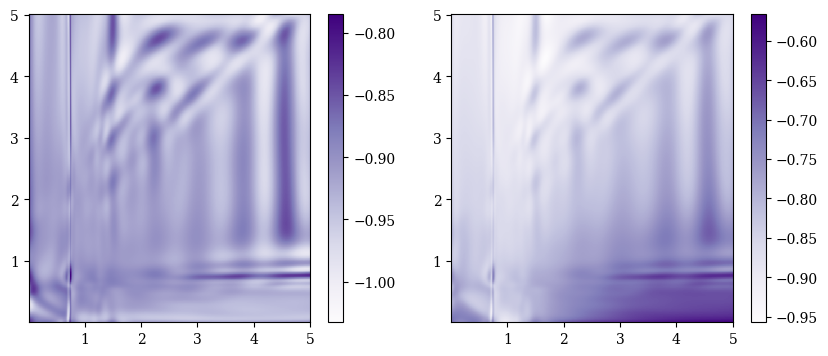

In [4]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))

h1 = ax1.pcolormesh(X1s, X2s, F1, shading='auto',cmap='Purples')
h2 = ax2.pcolormesh(X1s, X2s, F2, shading='auto',cmap='Purples')

plt.colorbar(h1)
plt.colorbar(h2)
plt.show()

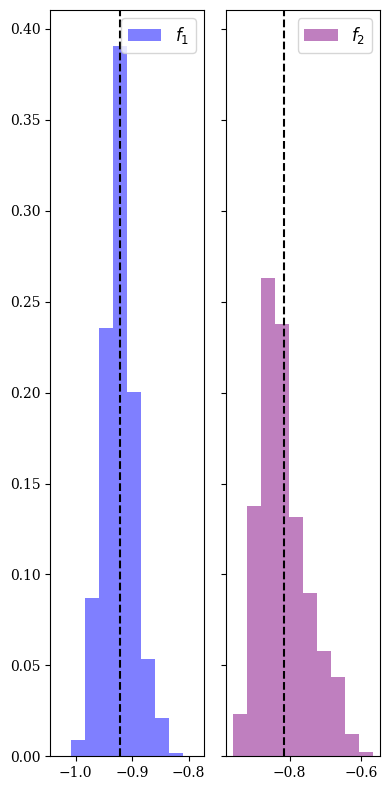

In [5]:
f_eval = f.eval()

x_vals_yup = np.linspace(0.01, 5, 501)
y_vals_yup = np.linspace(0.01, 5, 501)

X1s, X2s= np.meshgrid(x_vals_yup,y_vals_yup)

X12s = np.vstack((X1s.reshape(-1),X2s.reshape(-1))).T
X12s = torch.tensor(X12s,dtype=torch.float32)

with torch.no_grad():
    f_out = f_eval(X12s)

F1 = f_out[:,0].reshape(X1s.shape)
F2 = f_out[:,1].reshape(X1s.shape)



f1_flat = F1.flatten()
f2_flat = F2.flatten()

bins= 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 8),sharey=True)


weights1 = np.ones_like(f1_flat) / len(f1_flat)
weights2 = np.ones_like(f2_flat) / len(f2_flat)


ax1.hist(f1_flat, bins=bins, weights=weights1,color='blue',alpha=0.5,label=r'$f_1$')
ax1.axvline(f1_flat.mean(),linestyle='--',zorder=2,color='black')
ax1.legend(fontsize=12,)

ax2.hist(f2_flat, bins=bins, weights=weights2,color='purple',alpha=0.5,label=r'$f_2$')
ax2.axvline(f2_flat.mean(),linestyle='--',zorder=2,color='black')
ax2.legend(fontsize=12,)

plt.tight_layout()
plt.show()

(array([4.51294522e-03, 3.64257394e-01, 3.52702787e+00, 9.53776438e+00,
        1.58123549e+01, 8.11441712e+00, 2.17378377e+00, 8.49884292e-01,
        6.52763717e-02, 6.12469661e-03]),
 array([-1.03251839, -1.00779986, -0.98308122, -0.9583627 , -0.93364412,
        -0.90892553, -0.88420695, -0.85948837, -0.83476985, -0.81005126,
        -0.78533268]),
 <BarContainer object of 10 artists>)

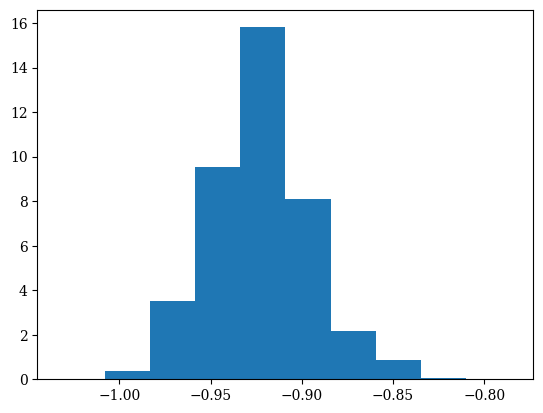

In [6]:
plt.hist(f1_flat,density=True)

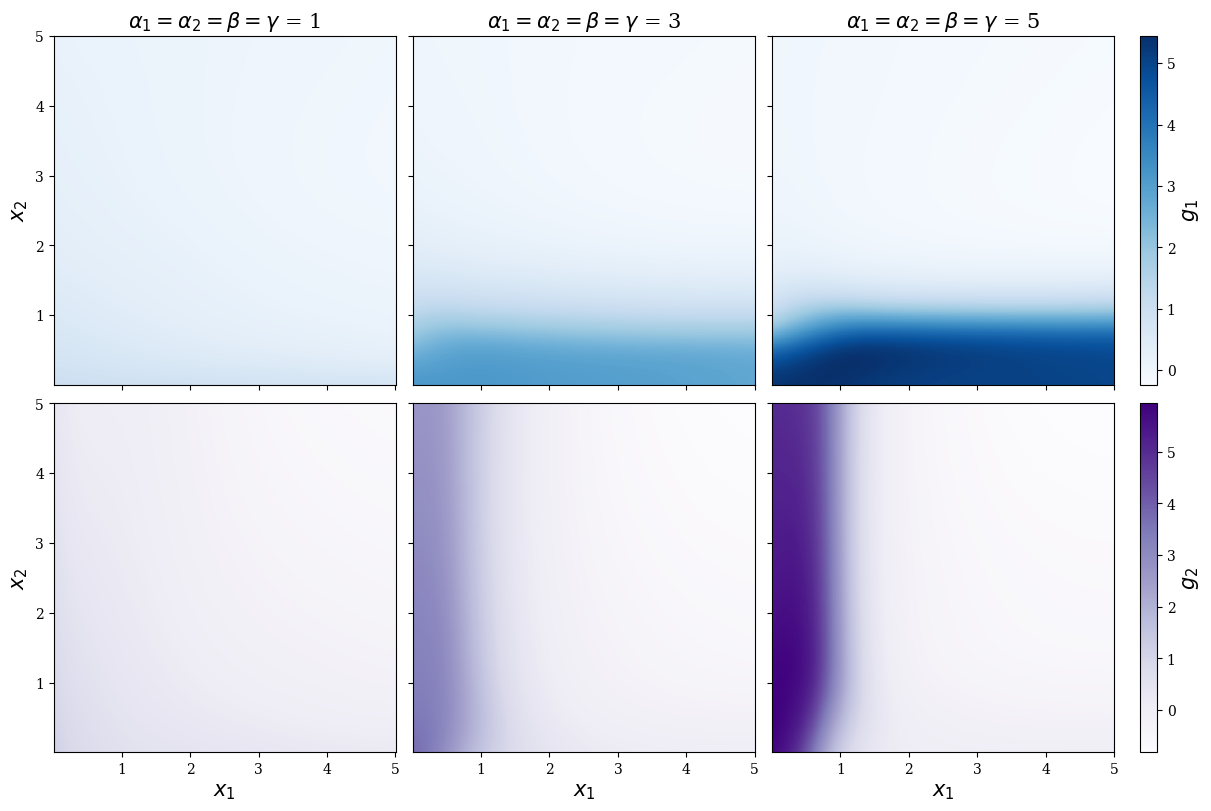

In [7]:
g_eval = g.eval()

nrows = 2
ncols = 3
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 8),
constrained_layout=True,
sharey=True,
sharex=True)
axs = axs.flatten()

u_vals = [1, 3, 5]
G1_all, G2_all = [], []

# First pass: compute ranges
for ui in u_vals:
    u = [ui] * 4
    U = torch.tensor([u], dtype=torch.float32).expand(len(X12s), -1)
    with torch.no_grad():
        g_out = g_eval(X12s, U)
    G1_all.append(g_out[:, 0])
    G2_all.append(g_out[:, 1])

vmin1, vmax1 = torch.cat(G1_all).min(), torch.cat(G1_all).max()
vmin2, vmax2 = torch.cat(G2_all).min(), torch.cat(G2_all).max()

# Second pass: plot
for idx, ui in enumerate(u_vals):
    u = [ui] * 4
    U = torch.tensor([u], dtype=torch.float32).expand(len(X12s), -1)

    with torch.no_grad():
        g_out = g_eval(X12s, U)

    G1 = g_out[:, 0].reshape(X1s.shape)
    G2 = g_out[:, 1].reshape(X1s.shape)

    ax1 = axs[idx]
    ax2 = axs[idx + len(u_vals)]

    h1 = ax1.pcolormesh(
        X1s, X2s, G1, shading='auto', cmap='Blues',
        vmin=vmin1, vmax=vmax1
    )
    h2 = ax2.pcolormesh(
        X1s, X2s, G2, shading='auto', cmap='Purples',
        vmin=vmin2, vmax=vmax2
    )

for i, ax in enumerate(axs):
    row = i // ncols
    col = i % ncols

    # Only left column gets y-labels
    if col == 0:
        ax.set_ylabel(r"$x_2$",fontsize=15)
    else:
        ax.set_ylabel("")

    # Only bottom row gets x-labels
    if row == nrows - 1:
        ax.set_xlabel(r"$x_1$",fontsize=15)
    else:
        ax.set_xlabel("")

    if row == 0:
        ax.set_title(rf"$\alpha_1 = \alpha_2=\beta=\gamma$ = {u_vals[i]}",size=15)


# One colorbar per row
cbar1 = fig.colorbar(h1, ax=axs[:3], location='right', fraction=0.025, pad=0.02)
cbar2 = fig.colorbar(h2, ax=axs[3:], location='right', fraction=0.025, pad=0.02)

cbar1.set_label(r"$g_1$",fontsize=15)
cbar2.set_label(r"$g_2$",fontsize=15)




# plt.tight_layout()
plt.show()


In [8]:
savefig = True

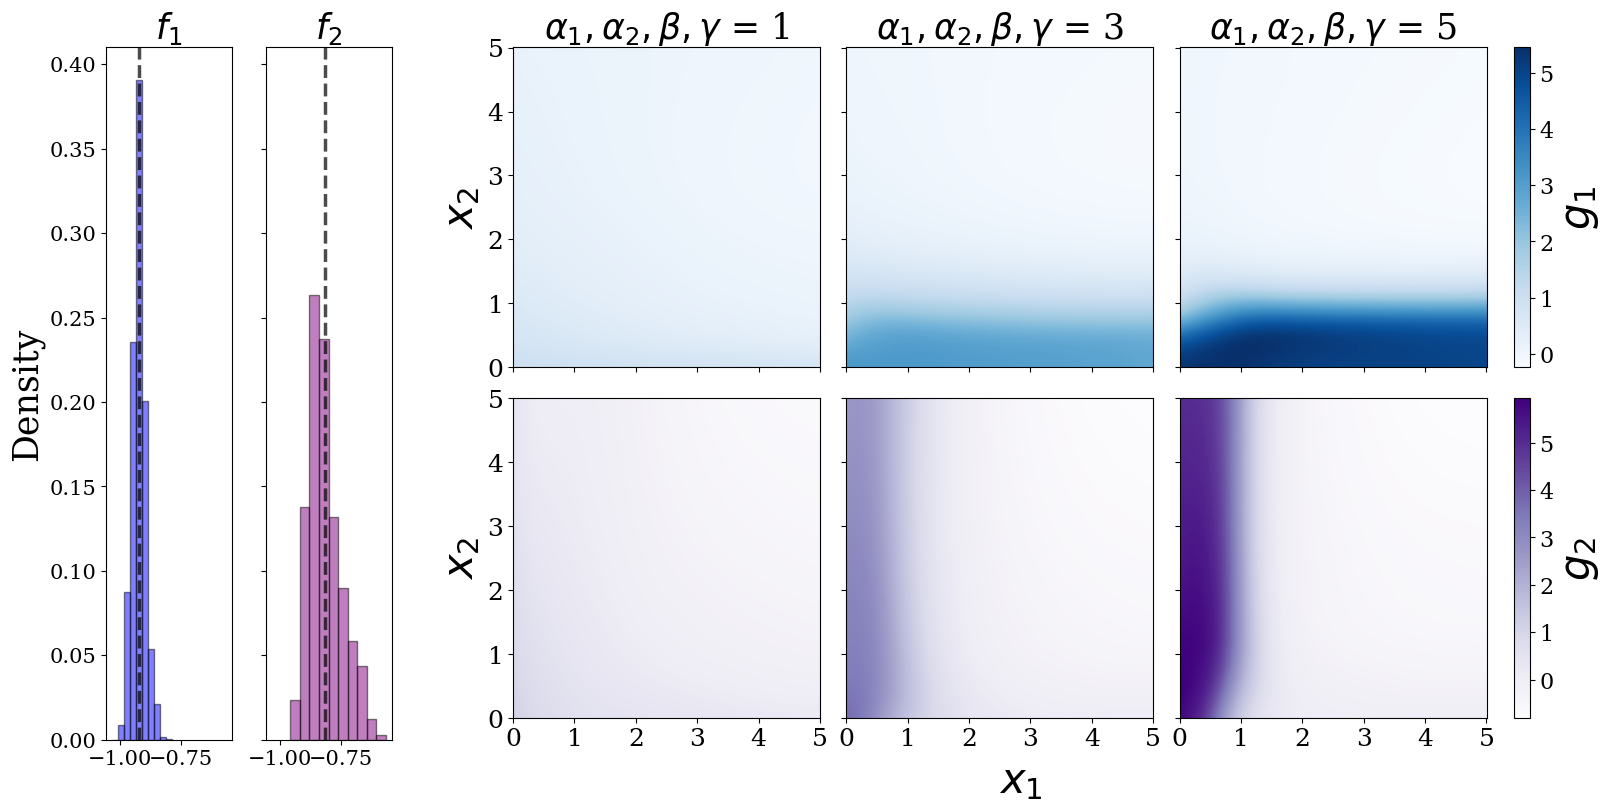

In [9]:
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[1, 3], wspace=0.05)

subfig_left = subfigs[0]
subfig_right = subfigs[1]

# ==========================================
# 1. SHARED DATA GENERATION
# ==========================================
x_vals_yup = np.linspace(.01, 5, 501)
y_vals_yup = np.linspace(0.01, 5, 501)

X1s, X2s = np.meshgrid(x_vals_yup, y_vals_yup)

X12s = np.vstack((X1s.reshape(-1), X2s.reshape(-1))).T
X12s = torch.tensor(X12s, dtype=torch.float32)

# ==========================================
# 2. LEFT PANEL (Histograms)
# ==========================================
f_eval = f.eval()

with torch.no_grad():
    f_out = f_eval(X12s)

F1 = f_out[:, 0].reshape(X1s.shape)
F2 = f_out[:, 1].reshape(X1s.shape)

f1_flat = F1.flatten()
f2_flat = F2.flatten()

# Create subplots within the left subfigure
axs_left = subfig_left.subplots(1, 2, sharey=True,sharex=True)
axL1, axL2 = axs_left

bins = 10
weights1 = np.ones_like(f1_flat) / len(f1_flat)
weights2 = np.ones_like(f2_flat) / len(f2_flat)

# Plot F1
axL1.hist(f1_flat, bins=bins, weights=weights1, color='blue',edgecolor='black', alpha=0.5,)
axL1.axvline(f1_flat.mean(), linestyle='--', zorder=2, color='black',lw=2.5,alpha=0.7)
axL1.set_ylabel("Density", fontsize=25)
axL1.set_title(r"$f_1$", fontsize=25) 
axL1.set_xlabel(" ", fontsize=20) 

# Plot F2
axL2.hist(f2_flat, bins=bins, weights=weights2, color='purple',edgecolor='black', alpha=0.5)
axL2.axvline(f2_flat.mean(), linestyle='--', zorder=2, color='black',lw=2.5,alpha=0.7)
axL2.set_title(r"$f_2$", fontsize=25) 
axL2.set_xlabel(" ", fontsize=20) 


# ==========================================
# 3. RIGHT PANEL (Heatmaps)
# ==========================================
g_eval = g.eval()

nrows = 2
ncols = 3
# Create subplots within the right subfigure
axs_right = subfig_right.subplots(nrows, ncols, sharex=True, sharey=True)
axs_flat_right = axs_right.flatten()

u_vals = [1, 3, 5]
G1_all, G2_all = [], []

# First pass: compute ranges
for ui in u_vals:
    u = [ui] * 4
    U = torch.tensor([u], dtype=torch.float32).expand(len(X12s), -1)
    with torch.no_grad():
        g_out = g_eval(X12s, U)
    G1_all.append(g_out[:, 0])
    G2_all.append(g_out[:, 1])

vmin1, vmax1 = torch.cat(G1_all).min(), torch.cat(G1_all).max()
vmin2, vmax2 = torch.cat(G2_all).min(), torch.cat(G2_all).max()


h1_mesh = None 
h2_mesh = None

for idx, ui in enumerate(u_vals):
    u = [ui] * 4
    U = torch.tensor([u], dtype=torch.float32).expand(len(X12s), -1)

    with torch.no_grad():
        g_out = g_eval(X12s, U)

    G1 = g_out[:, 0].reshape(X1s.shape)
    G2 = g_out[:, 1].reshape(X1s.shape)

    # Top row is G1, Bottom row is G2
    ax_top = axs_right[0, idx]
    ax_bot = axs_right[1, idx]

    h1_mesh = ax_top.pcolormesh(
        X1s, X2s, G1, shading='auto', cmap='Blues',
        vmin=vmin1, vmax=vmax1
    )
    h2_mesh = ax_bot.pcolormesh(
        X1s, X2s, G2, shading='auto', cmap='Purples',
        vmin=vmin2, vmax=vmax2
    )


    if idx == 0:
        ax_top.set_ylabel(r"$x_2$", fontsize=30)
        ax_bot.set_ylabel(r"$x_2$", fontsize=30)
    
    ax_top.set_title(rf"$\alpha_1, \alpha_2, \beta, \gamma$ = {u_vals[idx]}", size=25)

cbar1 = subfig_right.colorbar(h1_mesh, ax=axs_right[0, :], location='right', fraction=0.025, pad=0.02)
cbar2 = subfig_right.colorbar(h2_mesh, ax=axs_right[1, :], location='right', fraction=0.025, pad=0.02)

cbar1.set_label(r"$g_1$", fontsize=30)
cbar2.set_label(r"$g_2$", fontsize=30)


for ax in [axL1, axL2]:
    ax.tick_params(axis='both', which='major', labelsize=15)
#     ax.set_xticks([-1])


for ax in axs_right.flatten():
  
    
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_yticks([0,1,2,3,4,5])
    ax.tick_params(axis='both', which='major', labelsize=18, )


cbar1.ax.tick_params(labelsize=16,)
cbar2.ax.tick_params(labelsize=16,)

subfig_right.supxlabel(r"$x_1$",fontsize=30)

if savefig:
    plt.savefig("f-and-g-toggle.png")

plt.show()

In [10]:
F1.mean().item(), F2.mean().item(), F1.std().item(), F2.std().item()

(-0.9224156737327576,
 -0.8151668310165405,
 0.02719777636229992,
 0.06807056069374084)